In [1]:
## Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from summarytools import dfSummary
from scipy.stats import entropy
from scipy.stats import f_oneway



In [2]:
## Load Data

df_cars = pd.read_csv('/Users/samabrams/Data Analysis Projects/Car-Color-Trends-Project/02 Data/Prepared Data/Cars Consolidated Final')


In [3]:
## I need to merge the Ram and Dodge brands again, first.

df_cars['make'] = df_cars['make'].replace({
    'RAM': 'Dodge',
    'ram': 'Dodge', 
    'dodge tk': 'Dodge',
    'Ram': 'Dodge'  # just in case
})


In [4]:
## Check to make sure that worked

pd.set_option('display.max_rows', None)
df_cars['make'].value_counts()


make
Ford             84209
Chevrolet        59855
Nissan           50779
Toyota           39171
Dodge            34995
Honda            27082
Hyundai          21535
BMW              20455
Kia              17874
Chrysler         17186
Mercedes-Benz    15655
Jeep             15325
Infiniti         14454
Lexus            11725
Volkswagen       11521
GMC              10603
Mazda             8447
Cadillac          7641
Acura             5911
Audi              5773
Buick             5073
Subaru            5055
Lincoln           4951
Pontiac           4489
Mitsubishi        4177
Volvo             3734
MINI              3188
Saturn            2827
Land Rover        1993
Mercury           1983
Scion             1648
Porsche           1589
Jaguar            1443
Suzuki            1073
FIAT               851
Hummer             808
Saab               480
Smart              387
Oldsmobile         383
Other              229
Maserati           166
Bentley            144
Tesla              109
Aston 

In [5]:
df_cars.head()


,make,model,year,odometer,fuel_type,transmission,color,interior,sellingprice,vin,state,body,source
0,Maserati,Ghibli S Q4,2016,1000.0,Gasoline,Automatic,gray,Red,36000,Unknown,Unknown,Unknown,cars.com
1,Aston Martin,Martin Vantage Base,2022,1023.0,Gasoline,Automatic,blue,Brown,156900,Unknown,Unknown,Unknown,cars.com
2,Mercedes-Benz,Metris Base,2020,1025.0,Gasoline,Automatic,black,Beige,299000,Unknown,Unknown,Unknown,cars.com
3,Toyota,Sequoia Platinum,2023,1025.0,Hybrid,Automatic,black,Black,85000,Unknown,Unknown,Unknown,cars.com
4,Toyota,GR86 Premium,2022,1050.0,Gasoline,Automatic,gray,Black,40000,Unknown,Unknown,Unknown,cars.com


---
## Research Question 3: Comparison of Color Evolution Across Vehicle Types

In [6]:
## Note: vehicle type is referred to as "body" in the dataset

## First, let's get a value counts of vehicle types to see what we're working with

df_cars['body'].value_counts()


body
Sedan           236673
SUV             137049
Pickup Truck     45660
Minivan          24751
Hatchback        24694
Coupe            19285
Wagon            15593
Convertible      10439
Van               6211
Unknown           3994
Other             2852
Name: count, dtype: int64

In [7]:
## I'm going to consolidate 'unknown' and 'other' into one category titled "Unknown"

df_cars['body'] = df_cars['body'].replace('Other', 'Unknown')
df_cars['body'].value_counts()


body
Sedan           236673
SUV             137049
Pickup Truck     45660
Minivan          24751
Hatchback        24694
Coupe            19285
Wagon            15593
Convertible      10439
Unknown           6846
Van               6211
Name: count, dtype: int64

In [8]:
## Similar to the brand analysis, I'll focus on the major body types with the most listings

## First I need to define the Shannon diversity index function

def shannon_diversity(color_counts):
    """Calculate Shannon diversity index for color distribution"""
    if len(color_counts) <= 1:
        return 0
    proportions = color_counts / color_counts.sum()
    return entropy(proportions, base=2)


In [9]:
## Make a list that excludes 'Unknown' and 'Van' - Van doesn't have enough data to be valuable here
major_body_types = ['Sedan', 'SUV', 'Pickup Truck', 'Minivan', 'Hatchback', 'Coupe', 'Wagon', 'Convertible']

## Create empty list to hold results
body_diversity_results = []

## Loop through each year and body type to calculate diversity scores
for year in range(1996, 2013):
    year_data = df_cars[df_cars['year'] == year]
    
    for body_type in major_body_types:
        body_data = year_data[year_data['body'] == body_type]
        
        if len(body_data) >= 50:  # Lower threshold since we have fewer body types than brands
            color_counts = body_data['color'].value_counts()
            diversity_score = shannon_diversity(color_counts)
            
            body_diversity_results.append({
                'year': year,
                'body_type': body_type,
                'diversity_score': diversity_score,
                'total_vehicles': len(body_data),
                'unique_colors': len(color_counts)
            })

body_diversity_df = pd.DataFrame(body_diversity_results)
body_diversity_df.head(10).sort_values(by=['diversity_score'], ascending=False)


,year,body_type,diversity_score,total_vehicles,unique_colors
3,1997,Sedan,3.036819,734,11
8,1998,SUV,3.019053,299,11
7,1998,Sedan,2.999628,1094,11
0,1996,Sedan,2.990349,466,10
4,1997,SUV,2.900404,222,10
1,1996,SUV,2.833185,113,8
9,1998,Pickup Truck,2.716148,126,9
6,1997,Coupe,2.659833,139,9
5,1997,Pickup Truck,2.537484,119,8
2,1996,Coupe,2.533463,57,7


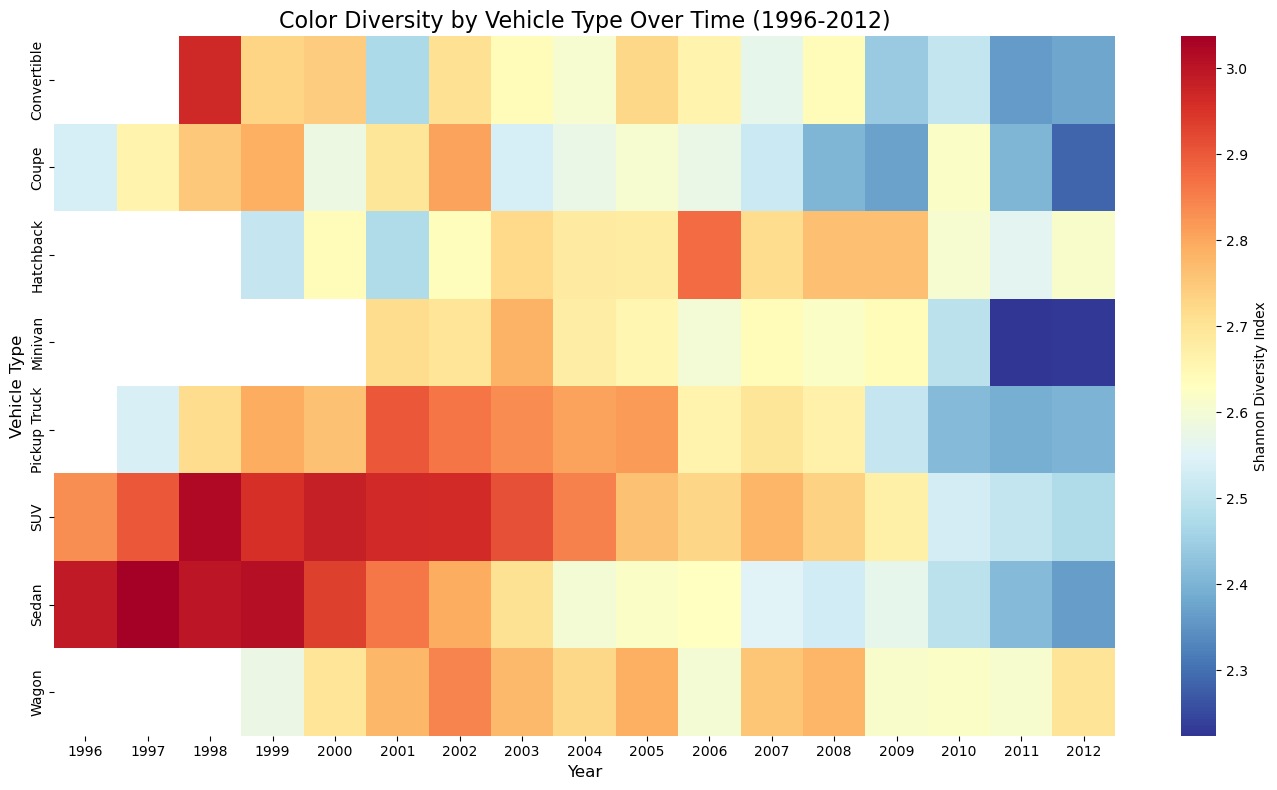

In [10]:
## Sedans and SUVs have the highest diversity scores in the early years.
## Let's visualize this trend with a heatmap.

## Create heatmap similar to what we did for brands
plt.figure(figsize=(14, 8))

## Pivot data for heatmap
body_diversity_pivot = body_diversity_df.pivot(index='body_type', columns='year', values='diversity_score')

## Create heatmap
sns.heatmap(body_diversity_pivot, cmap='RdYlBu_r', cbar_kws={'label': 'Shannon Diversity Index'})
plt.title('Color Diversity by Vehicle Type Over Time (1996-2012)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Vehicle Type', fontsize=12)
plt.tight_layout()
plt.show()


In [11]:
## Calculate average diversity scores for each body type (excluding Van and Unknown)

body_diversity_clean = body_diversity_df[~body_diversity_df['body_type'].isin(['Van', 'Unknown'])]

body_type_summary = body_diversity_clean.groupby('body_type').agg({
    'diversity_score': ['mean', 'min', 'max', 'std']
}).round(1)

body_type_summary.columns = ['avg_diversity', 'min_diversity', 'max_diversity', 'volatility']
body_type_summary = body_type_summary.sort_values('avg_diversity', ascending=False)

body_type_summary


,avg_diversity,min_diversity,max_diversity,volatility
body_type,,,,
SUV,2.8,2.5,3.0,0.2
Hatchback,2.7,2.5,2.9,0.1
Pickup Truck,2.7,2.4,2.9,0.2
Sedan,2.7,2.4,3.0,0.2
Wagon,2.7,2.6,2.8,0.1
Convertible,2.6,2.4,3.0,0.2
Coupe,2.6,2.3,2.8,0.1
Minivan,2.6,2.2,2.8,0.2


In [12]:
## Nothing earth-shattering here, the average diversity scores differ only slightly across vehicle types.
## I want to try one more thing before moving on - tipping point analysis for vehicle types, similar to what I did for brands.

# Define monochrome colors
monochrome_colors = ['black', 'white', 'gray']

# Calculate monochrome percentage by vehicle type and year
body_monochrome_results = []

for year in range(1996, 2013):
    year_data = df_cars[df_cars['year'] == year]
    
    for body_type in ['Sedan', 'SUV', 'Pickup Truck', 'Minivan', 'Hatchback', 'Coupe', 'Wagon', 'Convertible']:
        body_data = year_data[year_data['body'] == body_type]
        
        if len(body_data) >= 50:
            monochrome_count = body_data['color'].isin(monochrome_colors).sum()
            total_count = len(body_data)
            monochrome_pct = (monochrome_count / total_count) * 100
            
            body_monochrome_results.append({
                'year': year,
                'body_type': body_type,
                'monochrome_pct': monochrome_pct,
                'total_vehicles': total_count
            })

body_monochrome_df = pd.DataFrame(body_monochrome_results)
body_monochrome_df.head(20).sort_values(by=['monochrome_pct'], ascending=False)


,year,body_type,monochrome_pct,total_vehicles
15,1999,Hatchback,65.822785,79
17,1999,Wagon,61.016949,59
14,1999,Pickup Truck,59.872611,157
2,1996,Coupe,57.894737,57
16,1999,Coupe,55.958549,193
13,1999,SUV,55.082418,728
19,2000,Sedan,54.410441,2222
10,1998,Coupe,54.166667,144
12,1999,Sedan,53.274814,1481
18,1999,Convertible,52.713178,129


### Research Question 3: Vehicle Type Patterns - Key Findings

**Main Takeaway - No Significant Differences Across Vehicle Segments**

The vehicle type analysis reveals minimal meaningful variation in color diversity strategies across consumer vehicle segments:

- **Diversity scores**: Narrow 0.2-point range (2.6-2.8) across all vehicle types
- **Monochrome adoption timing**: All segments crossed 50% threshold around 1999, with no clear early/late adopter patterns
- **Universal trend impact**: The industry-wide shift to monochrome affected sedans, SUVs, pickup trucks, and other segments equally

**Key insight:** Vehicle type was not a significant factor in color strategy decisions. Unlike manufacturer-level differences (where Japanese brands led adoption by 3-7 years), consumer vehicle segments followed similar trajectories. This suggests the monochrome trend was driven by broader industry forces rather than segment-specific consumer preferences or functional requirements.

**Implication:** Color forecasting and strategy development should focus on manufacturer positioning and (potentially) regional preferences rather than vehicle type segmentation.

---
## Research Question #4 - Regional Variations in Color

In [13]:
## First, a value count for state distribution

df_cars['state'].value_counts()


state
FL         76871
CA         68978
PA         51180
TX         42661
GA         33059
NJ         25858
IL         22623
NC         20992
OH         20485
TN         15363
MI         15172
MO         14766
NV         12134
VA         11538
MD         10715
WI          9138
AZ          8487
MN          8368
CO          7546
WA          7146
MA          6498
NY          5571
IN          4262
SC          4094
Unknown     3994
NE          3950
ON          3002
PR          2660
LA          2135
UT          1781
MS          1679
HI          1176
OR          1123
QC          1095
AB           798
NM           163
OK            69
NS            46
AL            25
Name: count, dtype: int64

In [14]:
## To make the analysis more manageable, I'm going to group ONLY US states into regions

## Filter out canadian provinces and territories, Puerto Rico, and Unknowns
us_states = df_cars[~df_cars['state'].isin(['ON', 'QC', 'AB', 'NS', 'PR', 'Unknown'])].copy()
us_states['state'].value_counts()


state
FL    76871
CA    68978
PA    51180
TX    42661
GA    33059
NJ    25858
IL    22623
NC    20992
OH    20485
TN    15363
MI    15172
MO    14766
NV    12134
VA    11538
MD    10715
WI     9138
AZ     8487
MN     8368
CO     7546
WA     7146
MA     6498
NY     5571
IN     4262
SC     4094
NE     3950
LA     2135
UT     1781
MS     1679
HI     1176
OR     1123
NM      163
OK       69
AL       25
Name: count, dtype: int64

In [15]:
## Define US regions - I followed the US Census Bureau's definitions here EXCEPT for DE and MD, which I moved to the northeasat
northeast = ['CT', 'ME', 'MA', 'NH', 'NJ', 'NY', 'PA', 'RI', 'VT', 'DE', 'MD']
midwest = ['IL', 'IN', 'IA', 'KS', 'MI', 'MN', 'MO', 'NE', 'ND', 'OH', 'SD', 'WI']
south = ['AL', 'AR', 'FL', 'GA', 'KY', 'LA', 'MS', 'NC', 'OK', 'SC', 'TN', 'TX', 'VA', 'WV']
west = ['AK', 'AZ', 'CA', 'CO', 'HI', 'ID', 'MT', 'NV', 'NM', 'OR', 'UT', 'WA', 'WY']

## Create region mapping function
def assign_region(state):
    if state in northeast:
        return 'Northeast'
    elif state in midwest:
        return 'Midwest'
    elif state in south:
        return 'South'
    elif state in west:
        return 'West'
    else:
        return 'Other'

## Add region column
us_states['region'] = us_states['state'].apply(assign_region)

## Check the regional distribution
us_states['region'].value_counts()


region
South        208486
West         108534
Northeast     99822
Midwest       98764
Name: count, dtype: int64

In [16]:
## Now to calculate the diversity scores by region and year

## Calculate diversity scores by region and year
region_diversity_results = []

for year in range(1996, 2013):
    year_data = us_states[us_states['year'] == year]
    
    for region in ['Northeast', 'Midwest', 'South', 'West']:
        region_data = year_data[year_data['region'] == region]
        
        if len(region_data) >= 100:  # Ensure sufficient data points
            color_counts = region_data['color'].value_counts()
            diversity_score = shannon_diversity(color_counts)
            
            region_diversity_results.append({
                'year': year,
                'region': region,
                'diversity_score': diversity_score,
                'total_vehicles': len(region_data),
                'unique_colors': len(color_counts)
            })

region_diversity_df = pd.DataFrame(region_diversity_results)
region_diversity_df.head(20).sort_values(by=['diversity_score'], ascending=False)


,year,region,diversity_score,total_vehicles,unique_colors
8,1998,Midwest,3.094108,198,12
7,1998,Northeast,3.045931,362,11
4,1997,Midwest,3.030336,141,11
9,1998,South,3.019322,879,11
5,1997,South,2.997345,641,11
11,1999,Northeast,2.996812,550,10
13,1999,South,2.978003,1356,11
10,1998,West,2.972545,455,12
0,1996,Northeast,2.966180,122,10
16,2000,Midwest,2.960249,541,12


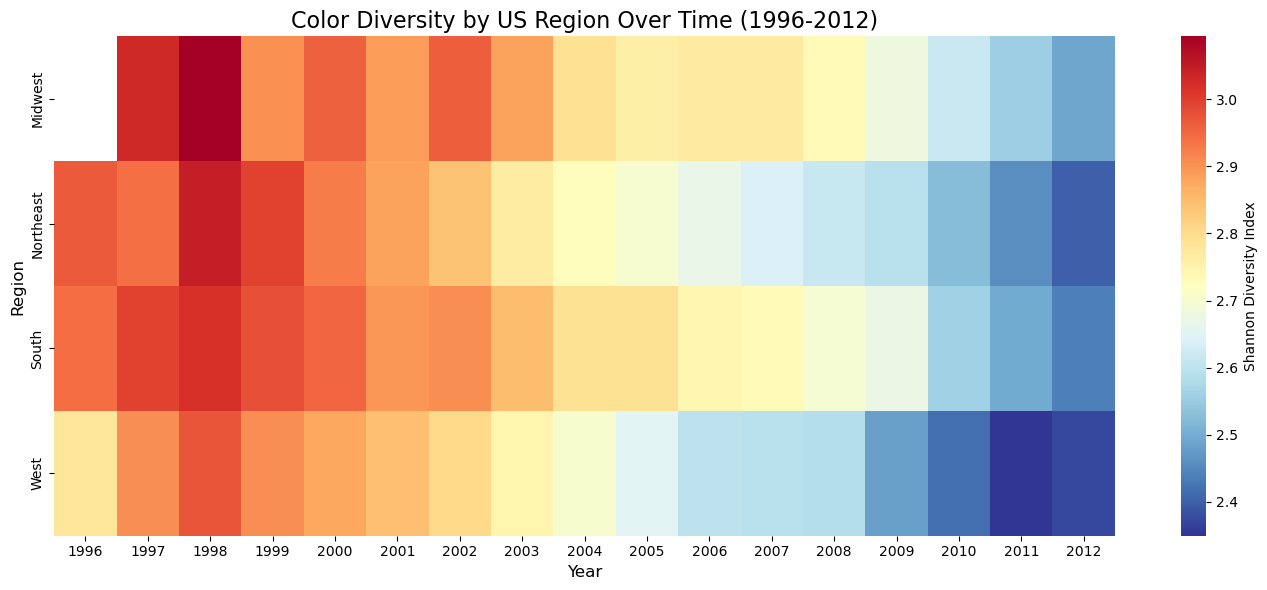

In [17]:
## And time for the heatmap

## Regional diversity heatmap
plt.figure(figsize=(14, 6))

## Pivot data for heatmap
region_diversity_pivot = region_diversity_df.pivot(index='region', columns='year', values='diversity_score')

## Create heatmap
sns.heatmap(region_diversity_pivot, cmap='RdYlBu_r', cbar_kws={'label': 'Shannon Diversity Index'})
plt.title('Color Diversity by US Region Over Time (1996-2012)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.tight_layout()
plt.show()


In [18]:
# Calculate average diversity by region
regional_summary = region_diversity_df.groupby('region').agg({
    'diversity_score': ['mean', 'min', 'max', 'std']
}).round(3)

regional_summary.columns = ['avg_diversity', 'min_diversity', 'max_diversity', 'volatility']
regional_summary = regional_summary.sort_values('avg_diversity', ascending=False)

regional_summary


,avg_diversity,min_diversity,max_diversity,volatility
region,,,,
Midwest,2.806,2.491,3.094,0.169
South,2.792,2.437,3.019,0.177
Northeast,2.747,2.399,3.046,0.196
West,2.682,2.349,2.973,0.197


#### Statistical Significance Test - Regional Diversity

Midwest shows highest color diversity (2.806), West shows lowest (2.682) - a 0.124-point spread.

**Why test this but not brands/body types:** Previous analyses showed either massive differences (brands: Japanese vs American 3-7 year gaps) or tiny differences (vehicle types: 0.2 points). Regional differences fall in the middle, in that they are large enough to potentially matter, but small enough to question.

With this statistical test, I hope to figure out whether geographic location actually influences color preferences or if the 0.124-point difference is just statistical noise from the large dataset.

In [19]:
## Get diversity scores by region
midwest_scores = region_diversity_df[region_diversity_df['region'] == 'Midwest']['diversity_score']
south_scores = region_diversity_df[region_diversity_df['region'] == 'South']['diversity_score']
northeast_scores = region_diversity_df[region_diversity_df['region'] == 'Northeast']['diversity_score']
west_scores = region_diversity_df[region_diversity_df['region'] == 'West']['diversity_score']

## ANOVA test
f_stat, p_value = f_oneway(midwest_scores, south_scores, northeast_scores, west_scores)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Statistically significant: {p_value < 0.05}")


F-statistic: 1.5165
P-value: 0.218871
Statistically significant: False


## Research Question 4: Regional Variations - Key Findings

**No Statistically Significant Regional Differences**

ANOVA testing revealed that apparent regional color diversity differences are not statistically significant:

- **Observed rankings**: Midwest (2.806) > South (2.792) > Northeast (2.747) > West (2.682)
- **Statistical test**: F-statistic = 1.5165, p-value = 0.219 (not significant at α = 0.05)
- **Conclusion**: The 0.124-point spread between highest and lowest regions could be due to random variation

**Key insight:** Geographic location does not significantly influence automotive color preferences. Despite visual patterns in the regional heatmap, statistical testing confirms that color diversity trends were **nationally uniform phenomena** rather than regionally-driven preferences.

**Implication:** Manufacturers can implement color strategies nationally without significant regional customization for diversity preferences. Climate, culture, and geographic factors appear to have minimal impact on color adoption patterns.

**Summary across all analyses:**
- **Manufacturers**: Significant differences (Japanese brands 3-7 years ahead)
- **Vehicle types**: No significant differences (0.2-point range)  
- **Brand tiers**: No significant differences (1.3-year spread)
- **Regions**: No significant differences (p = 0.219)

The data paints a picture where **individual manufacturer strategy** was the primary driver of color diversity patterns in the automotive market.